In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("drug_regulatory_classification_dataset.csv")

In [3]:
df.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [4]:
df.tail()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
59995,200,260.68,167.61,337160.40,2,6.04,2.79,0.92,67.01,32.99,...,East,Yes,No,No,60.31,73.67,25.44,2.97,0.95,Regulated Drug
59996,200,249.67,139.19,457366.23,2,8.51,1.94,0.86,50.66,49.34,...,South,Yes,No,No,31.87,38.08,56.10,6.75,0.91,Regulated Drug
59997,100,155.15,78.35,367705.08,4,6.45,2.36,0.85,26.03,73.97,...,South,Yes,Yes,No,35.96,19.06,25.10,9.75,0.60,Non-Regulated Drug
59998,500,42.46,19.05,259954.00,1,6.98,2.29,0.16,39.96,60.04,...,North,No,Yes,No,67.17,57.80,28.23,3.00,0.39,Regulated Drug
59999,250,153.99,83.04,267876.28,1,1.51,1.15,0.51,52.75,47.25,...,North,Yes,Yes,No,82.20,10.26,22.85,5.38,0.87,Non-Regulated Drug


In [5]:
df.shape

(60000, 30)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Dosage_mg                         60000 non-null  int64  
 1   Price_Per_Unit                    60000 non-null  float64
 2   Production_Cost                   60000 non-null  float64
 3   Marketing_Spend                   60000 non-null  float64
 4   Clinical_Trial_Phase              60000 non-null  int64  
 5   Side_Effect_Severity_Score        60000 non-null  float64
 6   Abuse_Potential_Score             60000 non-null  float64
 7   Prescription_Rate                 60000 non-null  float64
 8   Hospital_Distribution_Percentage  60000 non-null  float64
 9   Pharmacy_Distribution_Percentage  60000 non-null  float64
 10  Annual_Sales_Volume               60000 non-null  float64
 11  Regulatory_Risk_Score             60000 non-null  float64
 12  Appr

In [7]:
df.isnull().sum()

,0
Dosage_mg,0
Price_Per_Unit,0
Production_Cost,0
Marketing_Spend,0
Clinical_Trial_Phase,0
Side_Effect_Severity_Score,0
Abuse_Potential_Score,0
Prescription_Rate,0
Hospital_Distribution_Percentage,0
Pharmacy_Distribution_Percentage,0


In [8]:
df = df.dropna(subset=["Target_Regulatory_Class"])

In [9]:
df.isnull().sum()

,0
Dosage_mg,0
Price_Per_Unit,0
Production_Cost,0
Marketing_Spend,0
Clinical_Trial_Phase,0
Side_Effect_Severity_Score,0
Abuse_Potential_Score,0
Prescription_Rate,0
Hospital_Distribution_Percentage,0
Pharmacy_Distribution_Percentage,0


In [10]:
#Statistical Summary
df.describe()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Patent_Duration_Years,R&D_Investment_Million,Competitor_Count,Recall_History_Count,Adverse_Event_Reports,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
count,57000.000000,57000.000000,57000.000000,5.700000e+04,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,...,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,292.961404,253.367494,151.977048,2.666389e+05,2.503316,5.500050,2.846803,0.526378,47.404997,52.595003,...,9.985877,100.529168,11.956509,0.499930,4.993404,59.789144,39.974319,29.913025,5.472790,0.525417
std,215.016415,142.862060,91.953142,1.834675e+05,1.117474,2.604659,1.593382,0.245653,24.540401,24.540401,...,5.460524,57.303288,7.220956,0.709293,2.234971,23.049786,23.117852,17.319625,2.598576,0.244708
min,50.000000,5.020000,2.070000,1.000535e+04,1.000000,1.000000,0.010000,0.100000,5.000000,10.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.010000,1.000000,0.100000
25%,100.000000,130.027500,75.187500,1.330204e+05,2.000000,3.230000,1.610000,0.310000,26.097500,31.450000,...,5.000000,51.070000,6.000000,0.000000,3.000000,39.740000,19.870000,14.837500,3.220000,0.310000
50%,250.000000,252.765000,146.430000,2.579173e+05,3.000000,5.500000,2.630000,0.530000,47.450000,52.550000,...,10.000000,100.780000,12.000000,0.000000,5.000000,59.700000,39.970000,30.020000,5.465000,0.530000
75%,500.000000,377.550000,218.682500,3.817941e+05,4.000000,7.760000,3.880000,0.740000,68.550000,73.902500,...,15.000000,150.130000,18.000000,1.000000,6.000000,79.680000,59.940000,44.830000,7.710000,0.740000
max,650.000000,499.960000,398.290000,1.999699e+06,4.000000,10.000000,9.350000,0.950000,90.000000,95.000000,...,19.000000,200.000000,24.000000,6.000000,16.000000,100.000000,80.000000,60.000000,10.000000,0.950000


In [11]:
#Check Dublicates
df.duplicated().sum()

np.int64(0)

In [12]:
#Check Class Balance
df["Target_Regulatory_Class"].value_counts()

,count
Target_Regulatory_Class,
Non-Regulated Drug,42130
Regulated Drug,14870


In [13]:
df["Target_Regulatory_Class"].value_counts(normalize=True) * 100

,proportion
Target_Regulatory_Class,
Non-Regulated Drug,73.912281
Regulated Drug,26.087719


In [14]:
df.nunique()

,0
Dosage_mg,6
Price_Per_Unit,33846
Production_Cost,27383
Marketing_Spend,56964
Clinical_Trial_Phase,4
Side_Effect_Severity_Score,901
Abuse_Potential_Score,843
Prescription_Rate,86
Hospital_Distribution_Percentage,8494
Pharmacy_Distribution_Percentage,8494


In [15]:
df["Target_Regulatory_Class"].unique()

array(['Non-Regulated Drug', 'Regulated Drug'], dtype=object)

In [16]:
df["Target_Regulatory_Class"].value_counts()

,count
Target_Regulatory_Class,
Non-Regulated Drug,42130
Regulated Drug,14870


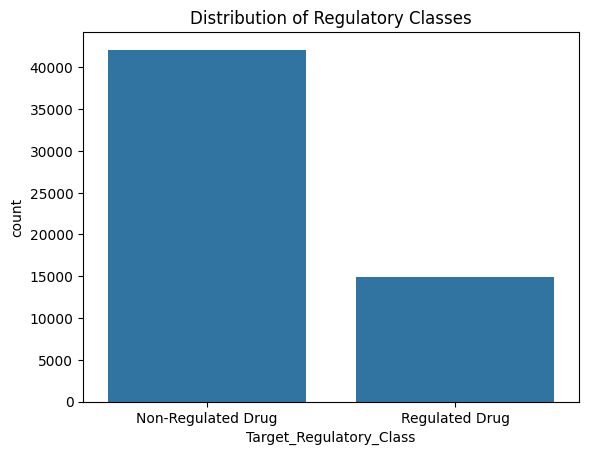

In [17]:
sns.countplot(x="Target_Regulatory_Class", data=df)
plt.title("Distribution of Regulatory Classes")
plt.show()

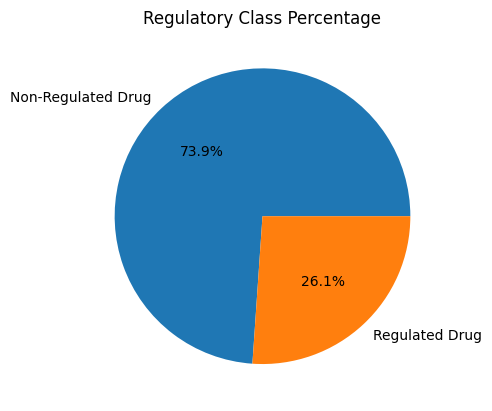

In [18]:
df["Target_Regulatory_Class"].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.title("Regulatory Class Percentage")
plt.show()

In [19]:
(df["Target_Regulatory_Class"].value_counts(normalize=True)) * 100

,proportion
Target_Regulatory_Class,
Non-Regulated Drug,73.912281
Regulated Drug,26.087719


In [20]:
df.select_dtypes(include='object').columns

Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance',
       'Target_Regulatory_Class'],
      dtype='object')

In [21]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 0 to 59999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Dosage_mg                         57000 non-null  int64  
 1   Price_Per_Unit                    57000 non-null  float64
 2   Production_Cost                   57000 non-null  float64
 3   Marketing_Spend                   57000 non-null  float64
 4   Clinical_Trial_Phase              57000 non-null  int64  
 5   Side_Effect_Severity_Score        57000 non-null  float64
 6   Abuse_Potential_Score             57000 non-null  float64
 7   Prescription_Rate                 57000 non-null  float64
 8   Hospital_Distribution_Percentage  57000 non-null  float64
 9   Pharmacy_Distribution_Percentage  57000 non-null  float64
 10  Annual_Sales_Volume               57000 non-null  float64
 11  Regulatory_Risk_Score             57000 non-null  float64
 12  Approval_

In [23]:
#Split Features & Target
X = df.drop("Target_Regulatory_Class", axis=1)
y = df["Target_Regulatory_Class"]

In [24]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 0.708421052631579


In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN:", accuracy_score(y_test, y_pred_knn))

KNN: 0.7436842105263158


In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 0.6957894736842105


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Random Forest: 0.7750877192982456


In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting: 0.7790350877192982


In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=2.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:44:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: 0.7285087719298246


In [32]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

for model, acc in results.items():
    print(model, ":", acc)

Logistic Regression : 0.708421052631579
KNN : 0.7436842105263158
Decision Tree : 0.6957894736842105
Random Forest : 0.7750877192982456
Gradient Boosting : 0.7790350877192982
XGBoost : 0.7285087719298246


In [33]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [34]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    f1_class1 = f1_score(y_test, y_pred)  # default = class 1
    recall_class1 = recall_score(y_test, y_pred)

    train_accuracy = model.score(X_train, y_train)
    gap = train_accuracy - test_accuracy

    return {
        "Model": name,
        "Test Accuracy": round(test_accuracy, 4),
        "F1-score (Class 1)": round(f1_class1, 4),
        "Recall (Class 1)": round(recall_class1, 4),
        "Train Accuracy": round(train_accuracy, 4),
        "Train-Test Gap": round(gap, 4)
    }

In [35]:
results = []

results.append(evaluate_model("Logistic Regression", lr, X_train, y_train, X_test, y_test))
results.append(evaluate_model("KNN", knn, X_train, y_train, X_test, y_test))
results.append(evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test))
results.append(evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test))
results.append(evaluate_model("Gradient Boosting", gb, X_train, y_train, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test))

In [36]:
import pandas as pd

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Test Accuracy,F1-score (Class 1),Recall (Class 1),Train Accuracy,Train-Test Gap
0,Logistic Regression,0.7084,0.5688,0.7290,0.7207,0.0122
1,KNN,0.7437,0.4068,0.3332,0.8184,0.0747
2,Decision Tree,0.6958,0.4201,0.4177,1.0000,0.3042
3,Random Forest,0.7751,0.4305,0.3222,1.0000,0.2249
4,Gradient Boosting,0.7790,0.4614,0.3588,0.7910,0.0120
5,XGBoost,0.7285,0.5622,0.6608,0.8508,0.1223
